TÂCHE 2 : Production et adaptation du notebook brainbeats_binary_classifier.ipynb
Ma deuxième tâche serait de produire le notebook du classificateur binaire brainbeats_binary_classifier en utilisant les données pré-traités trouvées sur Zenodo.

Voici les sous-tâches nécessaires:

Création et exécution complète d'un notebook original
Création d'un environnement virtuel
Adaptation du notebook au jeu de données pré-traités
Ajout de commentaires explicatifs
Sous-tâche si j'ai les capacité computationnelles:

Entrainer et tester le classificateur binaire sur plus d'un participant
Trouver et tester un autre type de classificateur binaire
Création d'une visualisation pour comparer les différents classificateurs utilisés
Sous-tâches supplémetaires:

Créer un script de validation de la structure du jeu de données

In [21]:
import numpy as np
from scipy.io import loadmat
import os
import urllib.request

from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold

In [22]:
# Let's download the data! It is available on Zenodo
Zenodo_Files = {
    'sub-005_Resp_Training.npy': 'https://zenodo.org/records/8275363/files/sub-005_Resp_Training.npy?download=1',
    'sub-005_Resp_Test_Mean.npy': 'https://zenodo.org/records/8275363/files/sub-005_Resp_Test_Mean.npy?download=1',
    'AcrossGenre_Order_Trn.mat':  'https://zenodo.org/records/8275363/files/AcrossGenre_Order_Trn.mat?download=1',
    'AcrossGenre_Order_Test.mat': 'https://zenodo.org/records/8275363/files/AcrossGenre_Order_Test.mat?download=1',
}

def download_data(data_path='./data'):
    """Download subject 005 data from Zenodo if not already present."""
    os.makedirs(data_path, exist_ok=True)
    for filename, url in Zenodo_Files.items():
        dest = os.path.join(data_path, filename)
        if os.path.exists(dest):
            print(f"Already exists, skipping: {filename}")
        else:
            print(f"Downloading {filename} ...")
            urllib.request.urlretrieve(url, dest)
            print(f"  Done.")

# --- CONFIGURATION ---
data_path = '../data'
sub = '005'

# --- Download if needed ---
download_data(data_path)

# Now, let's load the data

# --- Step 1: Load the fMRI .npy files ---
# mmap_mode='r' avoids loading the full dataset into RAM
X_train = np.load(f'{data_path}/sub-{sub}_Resp_Training.npy', mmap_mode='r')
X_test  = np.load(f'{data_path}/sub-{sub}_Resp_Test_Mean.npy', mmap_mode='r')


# --- Step 2: Transpose to shape (timepoints, voxels) ---
# Each row = one timepoint, each column = one voxel
X_train = X_train.T
X_test  = X_test.T

# --- step 3: load the .mat labels files ---
training_labels = loadmat(f'{data_path}/AcrossGenre_Order_Trn.mat')
test_labels     = loadmat(f'{data_path}/AcrossGenre_Order_Test.mat')

# --- step 4: Check shapes ---
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Training labels shape:", training_labels['across_genre_rn_trn'].shape)


# Extract valid key from test labels (ignore metadata keys)
key = [k for k in test_labels.keys() if not k.startswith('_')][0]
print("Test labels key:", key)
print("Test labels shape:", test_labels[key].shape)

Already exists, skipping: sub-005_Resp_Training.npy
Already exists, skipping: sub-005_Resp_Test_Mean.npy
Already exists, skipping: AcrossGenre_Order_Trn.mat
Already exists, skipping: AcrossGenre_Order_Test.mat
X_train shape: (4800, 53421)
X_test shape: (600, 53421)
Training labels shape: (12, 4, 10)
Test labels key: across_genre_rn_test
Test labels shape: (6, 4, 10)


Étape 2 : Construction des labels et filtrage Pop vs Classical
Les données contiennent 10 genres. Pour la classification binaire, on doit isoler uniquement les extraits de Pop (label 8) et Classical (label 2), puis réassigner leurs labels à 0 et 1 pour que le classificateur puisse les distinguer.

In [23]:
# --- Étape 2 : Explorer les labels ---
# Les labels sont des entiers qui encodent le genre musical de chaque extrait.
# On extrait les tableaux de labels et on regarde les valeurs uniques
# pour identifier quel entier correspond à quel genre.
y_train = training_labels['across_genre_rn_trn'].flatten()
y_test  = test_labels[key].flatten()

print("Labels uniques (entraînement):", np.unique(y_train))
print("Labels uniques (test):", np.unique(y_test))
print("Nombre d'extraits par label (entraînement):", {l: np.sum(y_train == l) for l in np.unique(y_train)})

Labels uniques (entraînement): [ 1  2  3  4  5  6  7  8  9 10]
Labels uniques (test): [ 1  2  3  4  5  6  7  8  9 10]
Nombre d'extraits par label (entraînement): {np.uint8(1): np.int64(48), np.uint8(2): np.int64(48), np.uint8(3): np.int64(48), np.uint8(4): np.int64(48), np.uint8(5): np.int64(48), np.uint8(6): np.int64(48), np.uint8(7): np.int64(48), np.uint8(8): np.int64(48), np.uint8(9): np.int64(48), np.uint8(10): np.int64(48)}


In [18]:
# --- Mapping des genres ---
# 1=blues, 2=classical, 3=country, 4=disco, 5=hiphop,
# 6=jazz, 7=metal, 8=pop, 9=reggae, 10=rock
GENRE_CLASSICAL = 2
GENRE_POP       = 8

# --- Étape 1 : Moyenne temporelle ---
# Chaque clip contient 10 TRs → on moyenne pour obtenir 1 vecteur par clip
n_tr     = 10
n_voxels = X_train.shape[1]

X_train_avg = X_train.reshape(480, n_tr, n_voxels).mean(axis=1)  # (480, voxels)
X_test_avg  = X_test.reshape(60, n_tr, n_voxels).mean(axis=1)    # (60, voxels)

# --- Étape 2 : Construction des labels ---
y_train_all = training_labels['across_genre_rn_trn'].reshape(-1)

key = [k for k in test_labels.keys() if not k.startswith('_')][0]
y_test_all = test_labels[key][:, 0, :].flatten()

# --- Étape 3 : Filtrage Pop et Classical ---
train_mask = np.isin(y_train_all, [GENRE_CLASSICAL, GENRE_POP])
test_mask  = np.isin(y_test_all,  [GENRE_CLASSICAL, GENRE_POP])

X_train_bin = X_train_avg[train_mask]
X_test_bin  = X_test_avg[test_mask]
y_train_bin = y_train_all[train_mask]
y_test_bin  = y_test_all[test_mask]

print("Taille entraînement après filtrage :", X_train_bin.shape)
print("Taille test après filtrage :", X_test_bin.shape)
print("Distribution entraînement :", {2: np.sum(y_train_bin == 2), 8: np.sum(y_train_bin == 8)})
print("Distribution test :", {2: np.sum(y_test_bin == 2), 8: np.sum(y_test_bin == 8)})

Taille entraînement après filtrage : (96, 53421)
Taille test après filtrage : (12, 53421)
Distribution entraînement : {2: np.int64(48), 8: np.int64(48)}
Distribution test : {2: np.int64(6), 8: np.int64(6)}


Étape 4 : Exploration des hyperparamètres avec GridSearchCV
Jusqu'ici on a utilisé des valeurs par défaut pour C et n_components. Le GridSearchCV va tester toutes les combinaisons possibles et trouver automatiquement la meilleure. C'est ce qu'on appelle la sélection de modèles.

Meilleurs hyperparamètres : {'linearsvc__C': 0.1, 'pca__n_components': 50}
Meilleur score CV : 0.676
Précision sur le test : 1.0


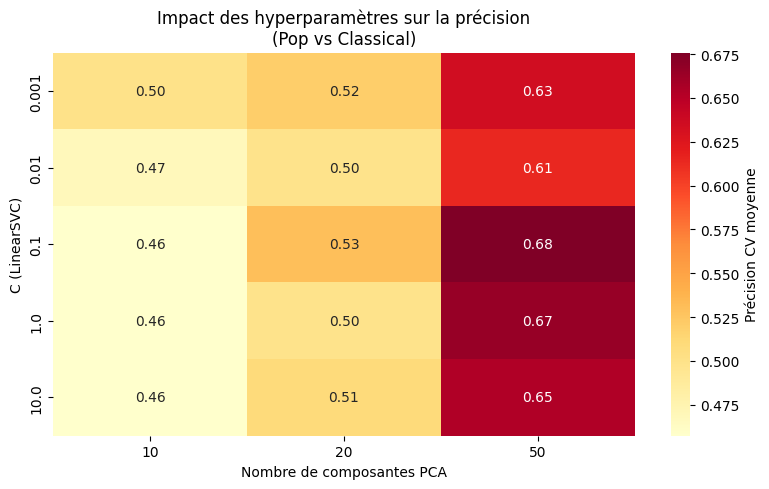

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Pipeline corrigé avec max_iter pour éviter le ConvergenceWarning ---
pipeline = Pipeline([
    ('scaler',    StandardScaler()),
    ('pca',       PCA()),
    ('linearsvc', LinearSVC(max_iter=10000))
])

param_grid = {
    'pca__n_components': [10, 20, 50],
    'linearsvc__C':      [0.001, 0.01, 0.1, 1, 10]
}

strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipeline, param_grid, cv=strat_kfold, scoring='accuracy')
grid_search.fit(X_train_bin, y_train_bin)

print("Meilleurs hyperparamètres :", grid_search.best_params_)
print("Meilleur score CV :", round(grid_search.best_score_, 3))
print("Précision sur le test :", round(grid_search.score(X_test_bin, y_test_bin), 3))

# --- Visualisation : heatmap des scores CV ---
# On réorganise les résultats du grid search en tableau 2D
results = pd.DataFrame(grid_search.cv_results_)
scores = results.pivot_table(
    index='param_linearsvc__C',
    columns='param_pca__n_components',
    values='mean_test_score'
)

plt.figure(figsize=(8, 5))
sns.heatmap(scores, annot=True, fmt='.2f', cmap='YlOrRd',
            cbar_kws={'label': 'Précision CV moyenne'})
plt.title('Impact des hyperparamètres sur la précision\n(Pop vs Classical)')
plt.xlabel('Nombre de composantes PCA')
plt.ylabel('C (LinearSVC)')
plt.tight_layout()
plt.show()